In [3]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [4]:
from parrot import py_predictor

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


# Prepping data for fit

In [5]:
exponential_fit = pd.read_csv("../../../output/ChopTFs_pipeline/speed/exponential_fit.csv", index_col = 0)
exponential_fit

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,A+C,A*k,1/k
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,1.156830,0.101060,0.269285,0.069876,-0.408963,0.100999,2.574025,0.667927,0.747866,4.208417,0.924506,ok,0.747866,0.311517,3.713533
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.629568,0.079913,0.132274,0.015466,0.342460,0.078549,5.240241,0.612717,1.971445,3.847695,0.988783,ok,1.972028,0.215549,7.560070
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.533139,0.098494,0.128593,0.012426,-0.266570,0.100362,5.390225,0.520850,1.265886,6.853707,0.983280,ok,1.266569,0.197152,7.776451
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.098801,0.101313,0.096377,0.021066,0.055955,0.096084,7.192037,1.572054,1.151371,6.613226,0.955792,ok,1.154756,0.105899,10.375916
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.508101,0.108744,0.117486,0.022559,0.037501,0.095994,5.899836,1.132839,1.544293,5.651303,0.954109,ok,1.545602,0.177181,8.511664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.093508,0.008916,-0.208122,0.073789,7.412734,0.706836,1.349461,8.897796,0.966920,ok,1.355182,0.146181,10.694315
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.120782,0.082873,0.080102,0.017744,0.010666,0.080531,8.653300,1.916833,1.122281,8.416834,0.969677,ok,1.131448,0.089777,12.484073
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.111316,0.014868,-0.181693,0.102116,6.226831,0.831686,1.415154,7.334669,0.977314,ok,1.417164,0.177979,8.983418
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.084823,0.012658,0.000967,0.104688,8.171657,1.219457,1.238982,8.056112,0.970036,ok,1.246658,0.105664,11.789209


In [6]:
exponential_fit[["ADseq", "A*k"]].to_csv("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_speed_input.txt", sep="\t", header=False)

In [7]:
exponential_fit[["ADseq", "A+C"]].to_csv("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_strength_input.txt", sep="\t", header=False)

In [8]:
exponential_fit[["ADseq", "k"]].to_csv("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_speed_input_k.txt", sep="\t", header=False)

# ChopTFs trained models

In [9]:
def return_preds(path):
    choptf_speed_preds = pd.read_csv(path, sep = "\t", header = None)
    choptf_speed_preds["class"] = choptf_speed_preds[0].str.split("_").str[1].str.split(" ").str[0]
    choptf_speed_preds["seq"] = choptf_speed_preds[0].str.split(" ").str[1].str.split(" ").str[0]
    choptf_speed_preds["val"] = choptf_speed_preds[0].str.split(" ").str[2].astype(float)
    choptf_speed_preds = choptf_speed_preds.drop(columns = 0)
    choptf_speed_preds = pd.pivot(choptf_speed_preds, index = "seq", columns = "class", values='val').reset_index()
    return choptf_speed_preds

In [10]:
choptf_speed_preds = return_preds("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_speed_predictions.tsv")
choptf_speed_preds

class,seq,PRED,TRUE
0,AFNKGMKNIDEGPETENDATENSLTTILNDLEGPLEDFSE,0.215799,0.074929
1,AGPGNNDLDDTDTDNQQFFLSDMNLNGSSVFENVFDDDDD,0.228937,0.124559
2,AHVIEKIWLKDWSNMNKALEEVCYDMGSLREATEYALNMV,0.104276,0.080567
3,ALHNSETMDLLGTLSHGNDFALEYNFDFTLLNEIDMLIGG,0.226338,0.203632
4,ALLEVLDPEQNNSFLDNYLDIPIDLSKVLFVCTANSLETI,0.139970,0.122346
...,...,...,...
122,WTGSLDPNLKKGKWTQEEDEQLLKAYEEHGPHWLSISMDI,0.122012,0.108148
123,YKNHFYEYVYPSLPFIELEIFEESLSQTIFPDPNNPSKVQ,0.103619,0.176862
124,YLNESEETKQNLRCIWFWALFLDVSTSYDIGNPPSISDDL,0.111186,0.057172
125,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,0.146728,0.089777


In [11]:
choptf_speed_k_preds = return_preds("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_speed_k_predictions.tsv")
choptf_speed_k_preds

class,seq,PRED,TRUE
0,AHEIGLHLNPEAWSNVYEDELSIMDFEVRSRIYWGCYIAD,0.102589,0.109138
1,AHVIEKIWLKDWSNMNKALEEVCYDMGSLREATEYALNMV,0.091950,0.070289
2,AILGELEQIKYNQIAISKDLLRINKDNELLWQENMMARER,0.087568,0.089870
3,ANNDDFDDLLSVASMNSNYLLPVNSHGYKHISNLDELDDL,0.099706,0.105761
4,CLPKSLGDVYLSSSDIAELFQEFATKYHQFLPVVDLSKGA,0.096286,0.069253
...,...,...,...
122,YDMFFRDSSKEGNNLFGEFLEDDDDDKKAANMSDDESSLI,0.083822,0.083896
123,YEVLCEYLTDFFASDFYDSYQIVHKEKVLRDLQDCFVKGP,0.104248,0.079839
124,YILNNENDDGLDNLLGMDYYNIDDLLTQELRDLDIPLVPS,0.095293,0.144339
125,YLNESEETKQNLRCIWFWALFLDVSTSYDIGNPPSISDDL,0.101254,0.056222


In [12]:
choptf_strength_preds = return_preds("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_strength_predictions.tsv")
choptf_strength_preds

class,seq,PRED,TRUE
0,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.519283,1.972028
1,ALPDDLYFTDFVSPFTAAATTSVTTKTVKDTTPATNHMDD,1.143222,1.085339
2,ANNDDFDDLLSVASMNSNYLLPVNSHGYKHISNLDELDDL,1.463037,1.452484
3,ARDEILPLRLQFNEFIQIMANIDQEGSKQADRMAKYLHIR,0.747855,1.387782
4,ASTNTSSALNCQSYTNNQDIMDILFQVTSGSVWDEFFVRS,1.338550,1.852118
...,...,...,...
122,VSNPGDNPPPADNGEEYLTLNDFNDLNIDWSTTGDNGELD,1.661274,1.754190
123,WFWALFLDVSTSYDIGNPPSISDDLLDLSIFTAQNFQSPS,1.446808,1.859544
124,WICQMHINQPDYMFSSQLRQDGDIEAQLEAIRYYEDVVVN,1.027500,1.265221
125,YEVLCEYLTDFFASDFYDSYQIVHKEKVLRDLQDCFVKGP,1.314954,1.085725


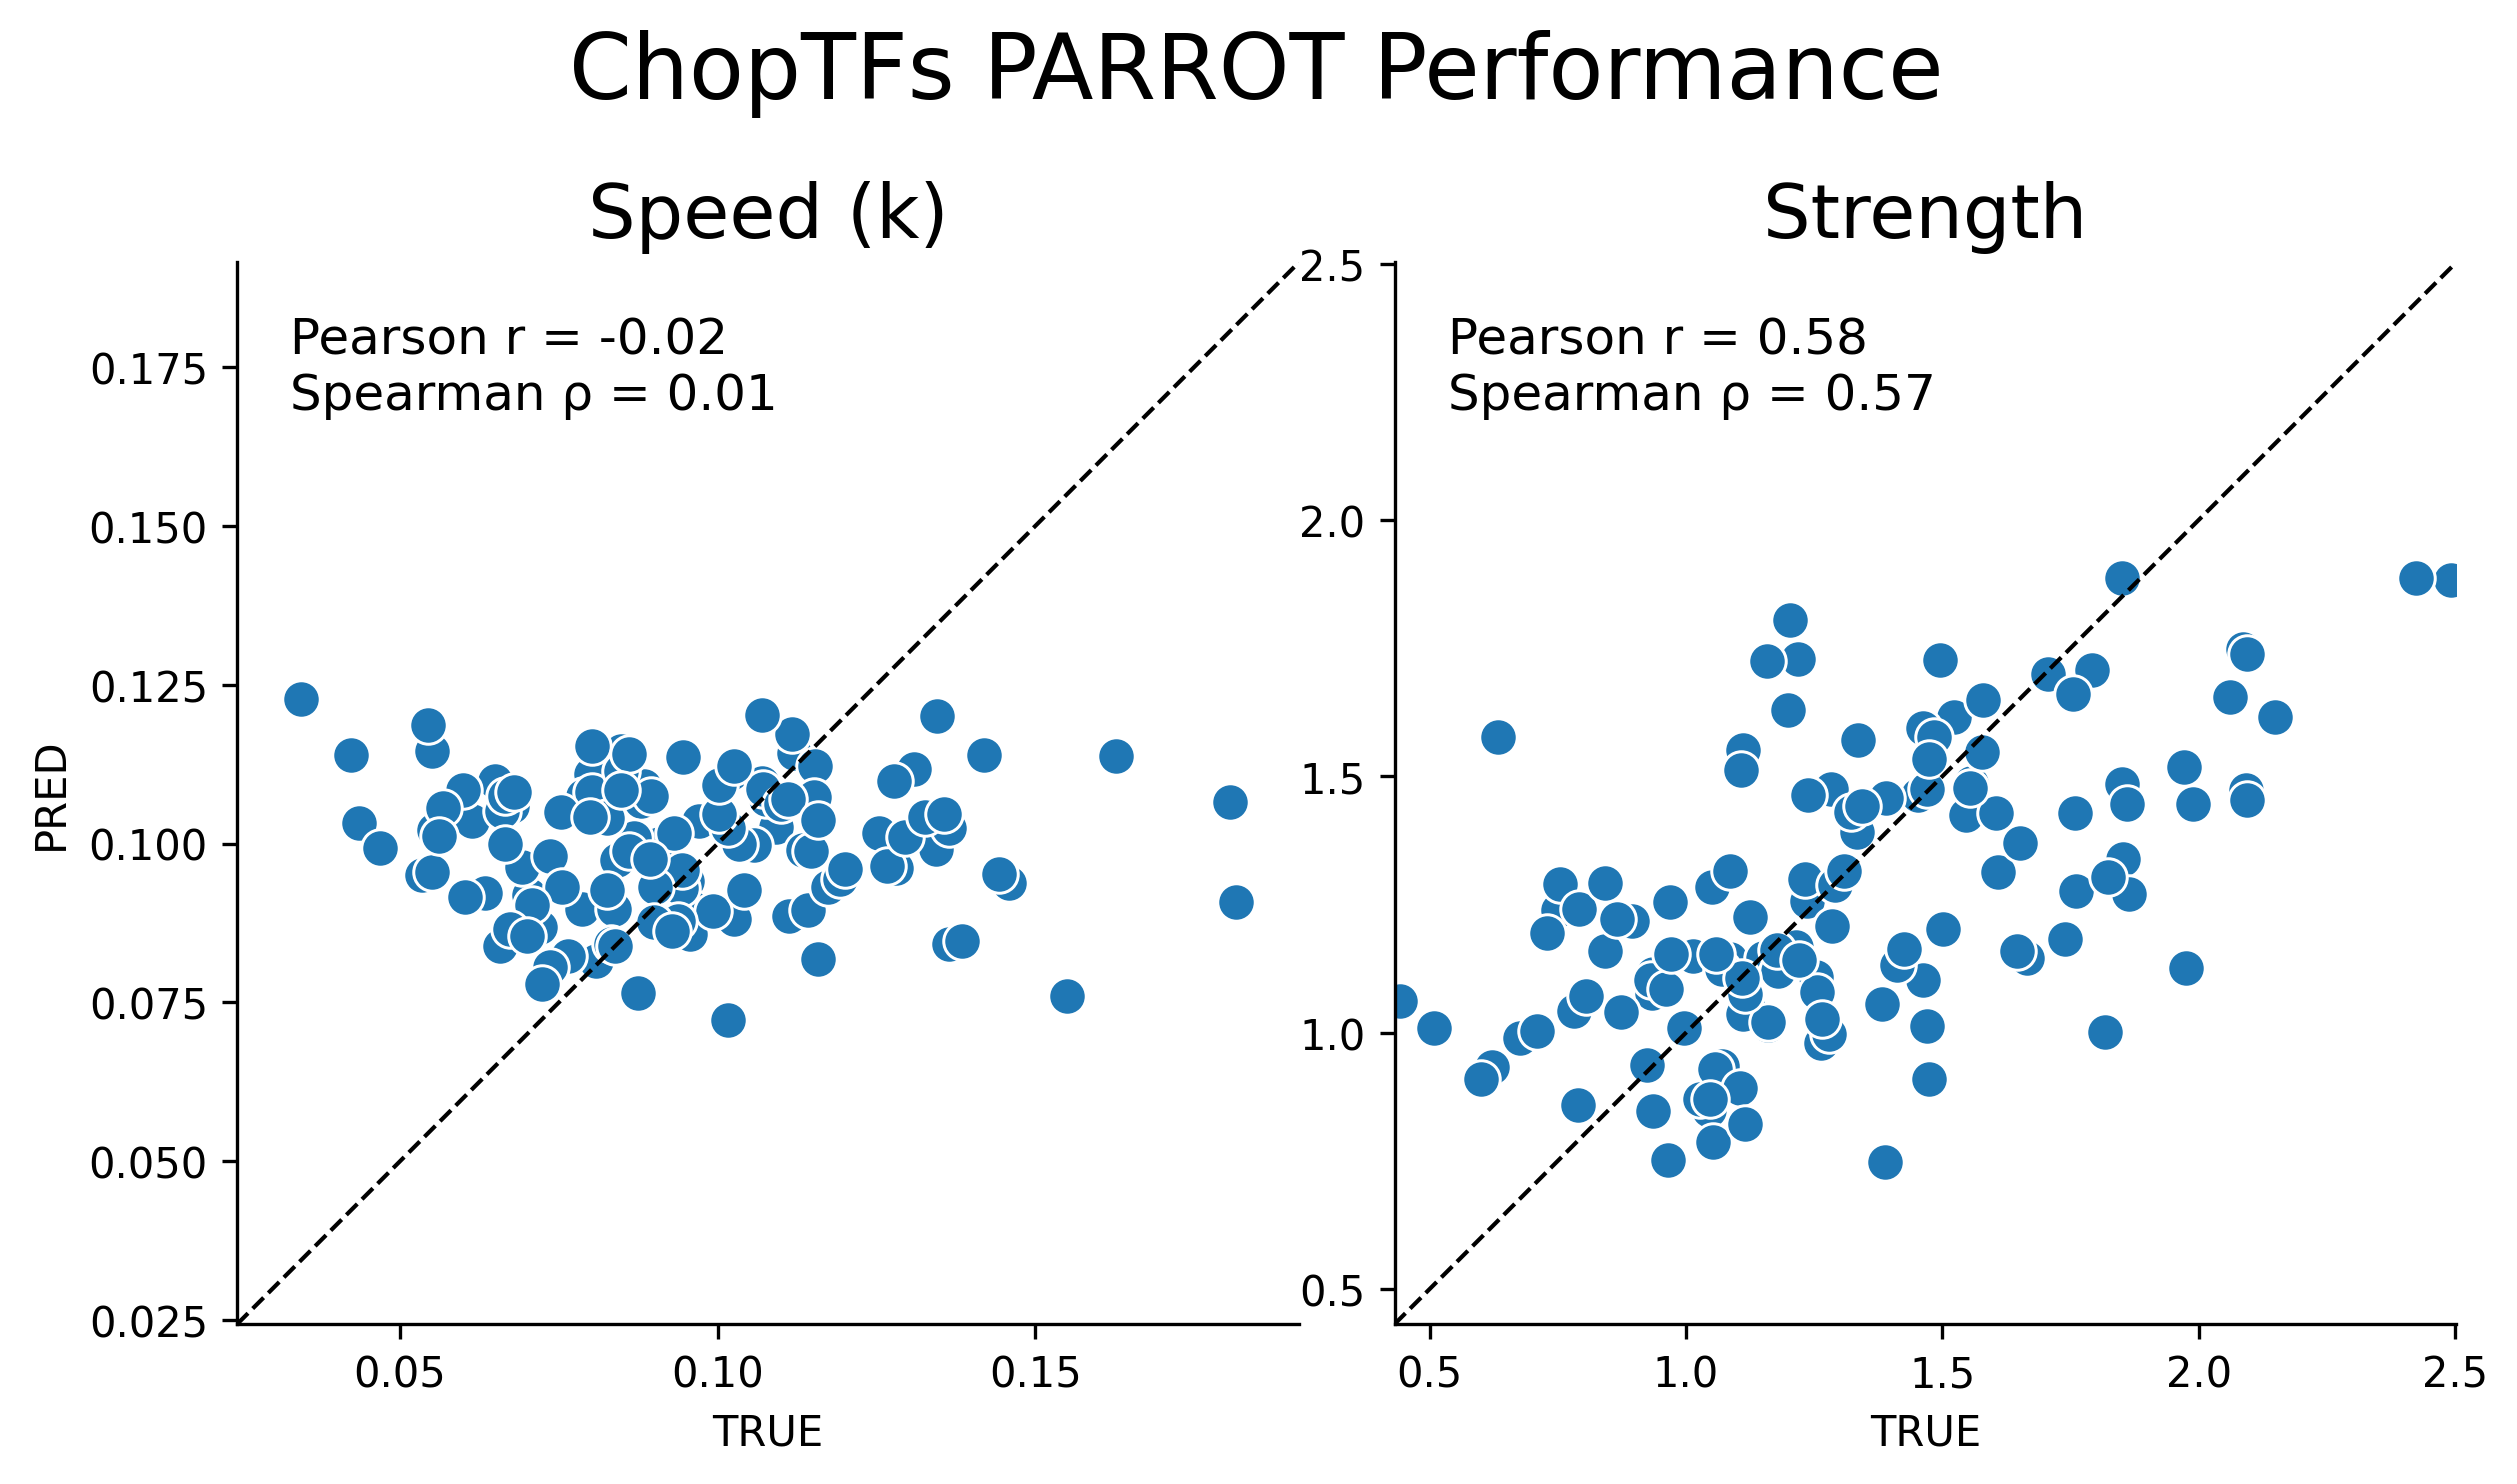

In [13]:
fig,axs = plt.subplots(1,2, dpi = 300, figsize = (8,5))

sns.set_context('talk')



ax = axs[0]
x = choptf_speed_k_preds["TRUE"]
y = choptf_speed_k_preds["PRED"]

sns.scatterplot(data=choptf_speed_k_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_title("Speed (k)")

ax = axs[1]
x = choptf_strength_preds["TRUE"]
y = choptf_strength_preds["PRED"]

sns.scatterplot(data=choptf_strength_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_ylabel("")
ax.set_title("Strength")

fig.suptitle("ChopTFs PARROT Performance")
fig.tight_layout(pad = 0)
sns.despine()
plt.show()

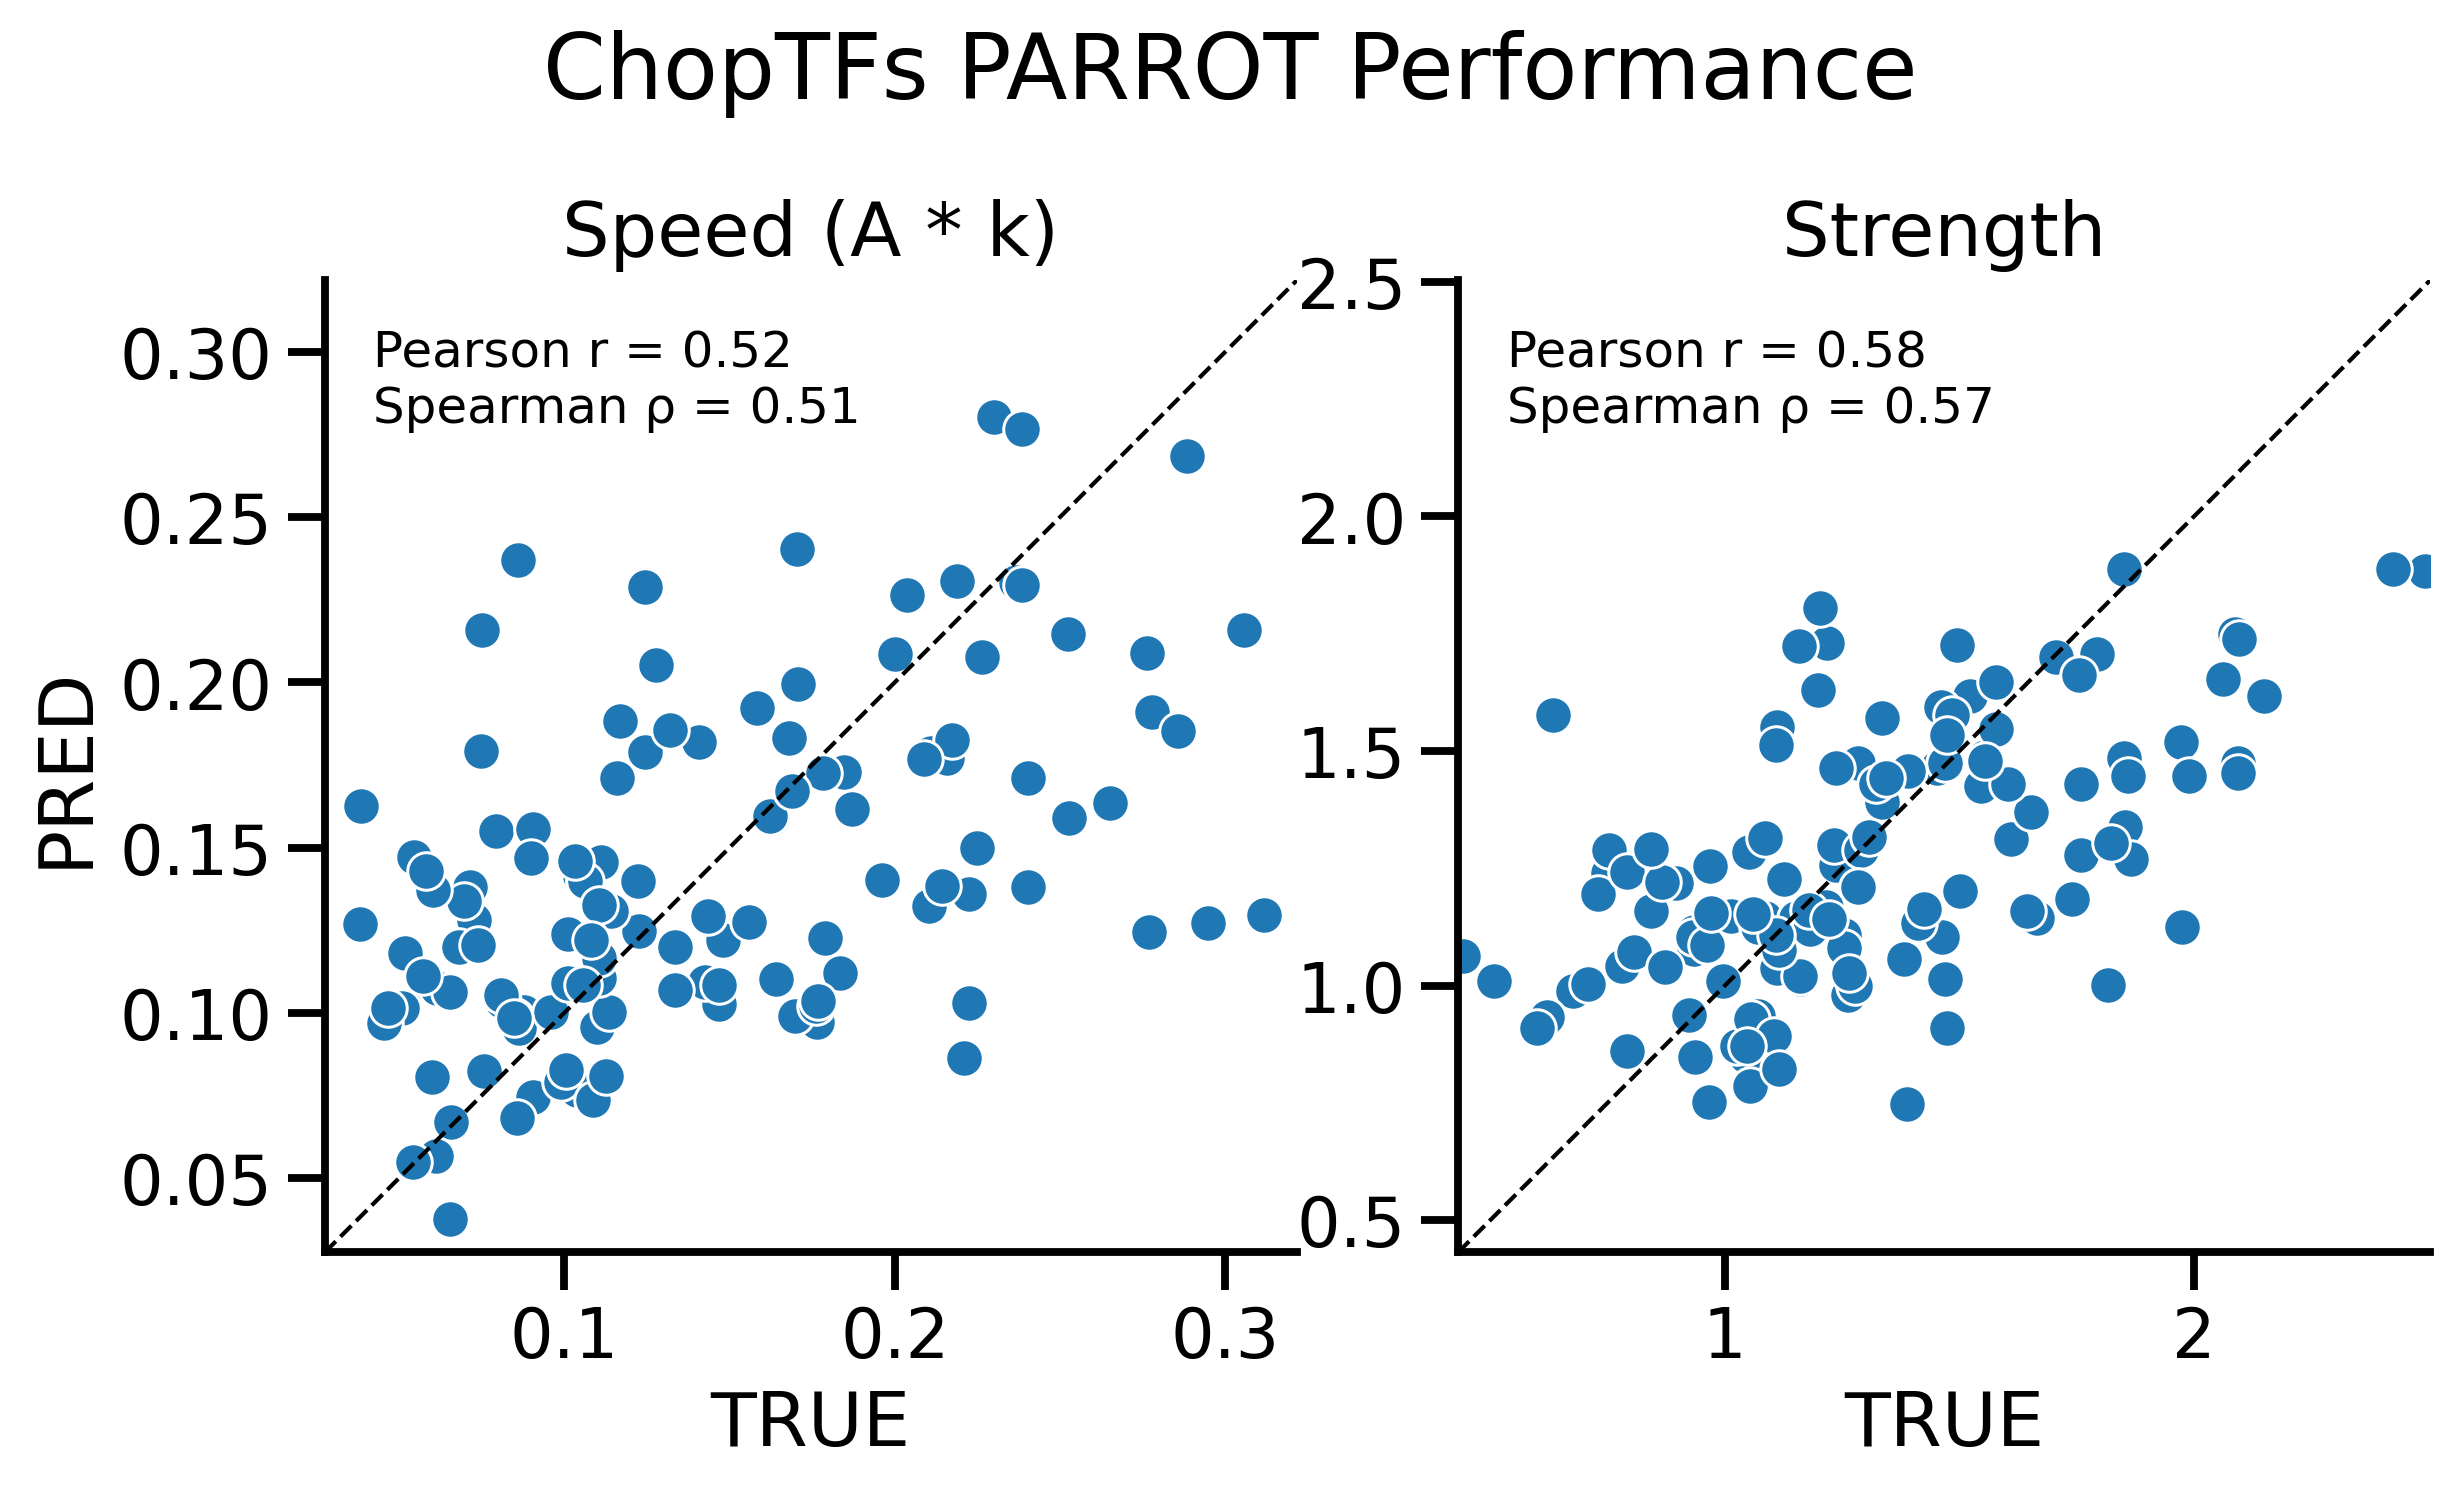

In [14]:
fig,axs = plt.subplots(1,2, dpi = 300, figsize = (8,5))

sns.set_context('talk')



ax = axs[0]
x = choptf_speed_preds["TRUE"]
y = choptf_speed_preds["PRED"]

sns.scatterplot(data=choptf_speed_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_title("Speed (A * k)")

ax = axs[1]
x = choptf_strength_preds["TRUE"]
y = choptf_strength_preds["PRED"]

sns.scatterplot(data=choptf_strength_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_ylabel("")
ax.set_title("Strength")

fig.suptitle("ChopTFs PARROT Performance")
fig.tight_layout(pad = 0)
sns.despine()
plt.show()

# GCN4 trained model

In [15]:
GCN4_train_speed_predictor = py_predictor.Predictor("../../../output/GCN4_pipeline/speed/PARROT/exponential_speed", 
                                                dtype="sequence")
GCN4_train_speed_predictor

In [16]:
GCN4_train_speed_k_predictor = py_predictor.Predictor("../../../output/GCN4_pipeline/speed/PARROT/exponential_speed_k", 
                                                dtype="sequence")
GCN4_train_speed_k_predictor

In [17]:
GCN4_train_speed_predictor.predict("AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS")[0]

np.float32(0.51897913)

In [18]:
choptf_speed_preds["GCN4_pred"] = choptf_speed_preds["seq"].apply(lambda seq: GCN4_train_speed_predictor.predict(seq)[0])
choptf_speed_preds

class,seq,PRED,TRUE,GCN4_pred
0,AFNKGMKNIDEGPETENDATENSLTTILNDLEGPLEDFSE,0.215799,0.074929,0.297695
1,AGPGNNDLDDTDTDNQQFFLSDMNLNGSSVFENVFDDDDD,0.228937,0.124559,0.532687
2,AHVIEKIWLKDWSNMNKALEEVCYDMGSLREATEYALNMV,0.104276,0.080567,0.185227
3,ALHNSETMDLLGTLSHGNDFALEYNFDFTLLNEIDMLIGG,0.226338,0.203632,0.747738
4,ALLEVLDPEQNNSFLDNYLDIPIDLSKVLFVCTANSLETI,0.139970,0.122346,0.710898
...,...,...,...,...
122,WTGSLDPNLKKGKWTQEEDEQLLKAYEEHGPHWLSISMDI,0.122012,0.108148,0.285673
123,YKNHFYEYVYPSLPFIELEIFEESLSQTIFPDPNNPSKVQ,0.103619,0.176862,0.479455
124,YLNESEETKQNLRCIWFWALFLDVSTSYDIGNPPSISDDL,0.111186,0.057172,0.564439
125,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,0.146728,0.089777,0.332303


In [19]:
choptf_speed_k_preds["GCN4_pred"] = choptf_speed_k_preds["seq"].apply(lambda seq: GCN4_train_speed_k_predictor.predict(seq)[0])
choptf_speed_k_preds

class,seq,PRED,TRUE,GCN4_pred
0,AHEIGLHLNPEAWSNVYEDELSIMDFEVRSRIYWGCYIAD,0.102589,0.109138,0.093013
1,AHVIEKIWLKDWSNMNKALEEVCYDMGSLREATEYALNMV,0.091950,0.070289,0.066517
2,AILGELEQIKYNQIAISKDLLRINKDNELLWQENMMARER,0.087568,0.089870,0.091388
3,ANNDDFDDLLSVASMNSNYLLPVNSHGYKHISNLDELDDL,0.099706,0.105761,0.126992
4,CLPKSLGDVYLSSSDIAELFQEFATKYHQFLPVVDLSKGA,0.096286,0.069253,0.119833
...,...,...,...,...
122,YDMFFRDSSKEGNNLFGEFLEDDDDDKKAANMSDDESSLI,0.083822,0.083896,0.176711
123,YEVLCEYLTDFFASDFYDSYQIVHKEKVLRDLQDCFVKGP,0.104248,0.079839,0.092048
124,YILNNENDDGLDNLLGMDYYNIDDLLTQELRDLDIPLVPS,0.095293,0.144339,0.156924
125,YLNESEETKQNLRCIWFWALFLDVSTSYDIGNPPSISDDL,0.101254,0.056222,0.165416


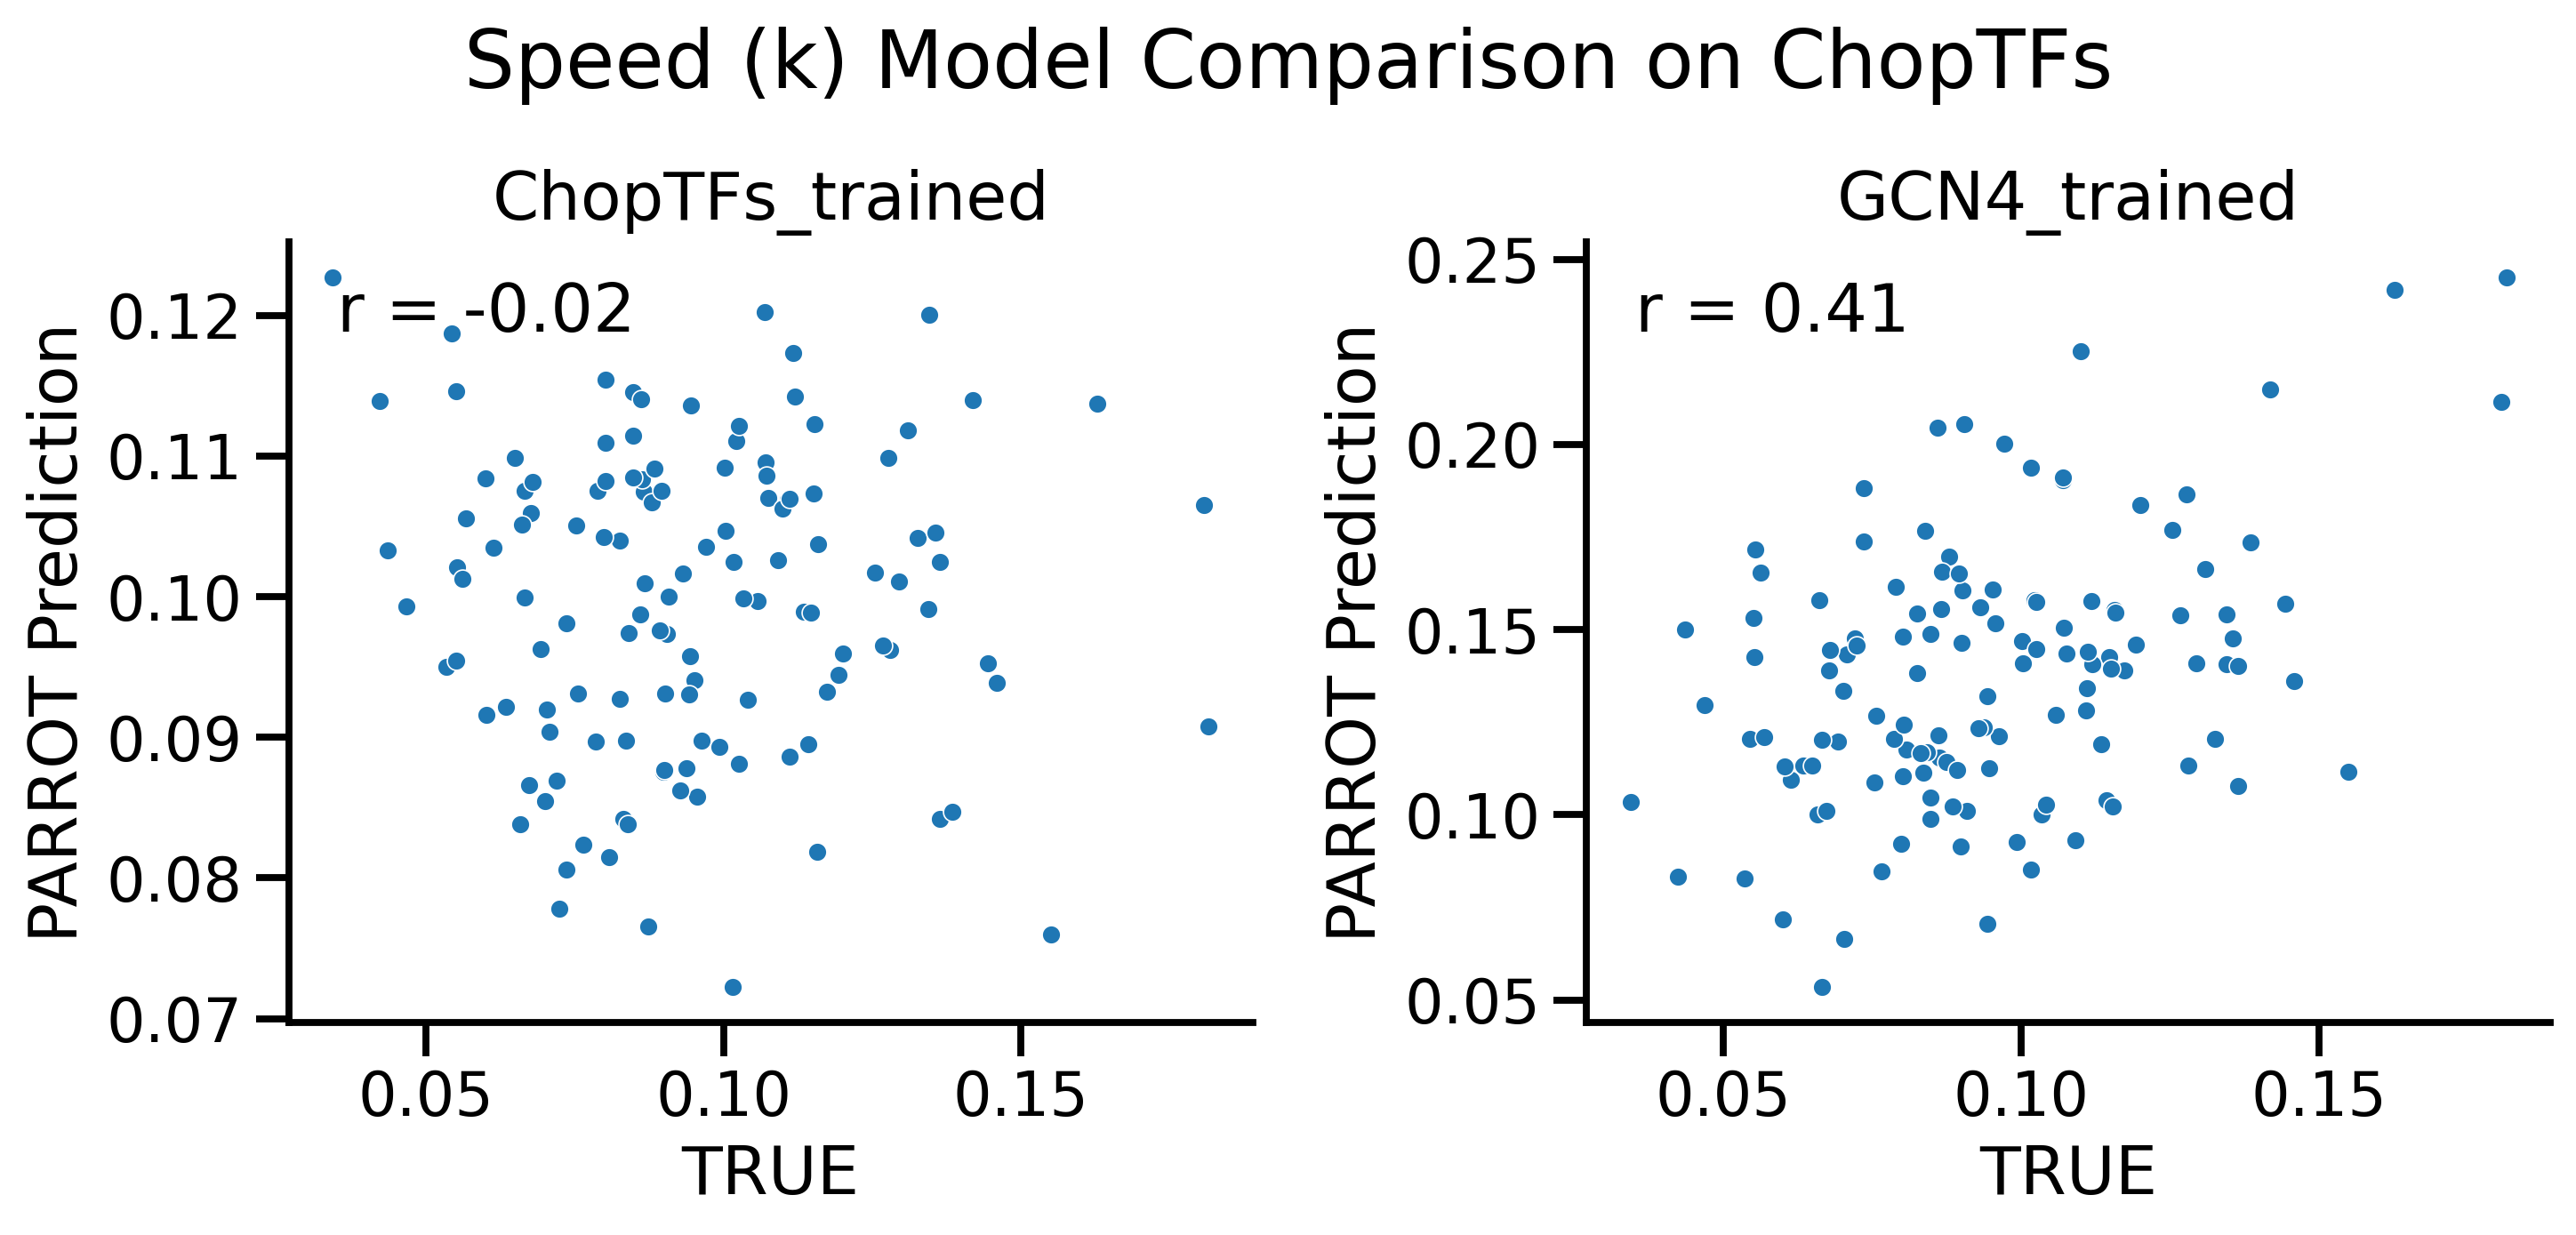

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


sns.set_context("talk")

df = choptf_speed_k_preds.rename(columns = {"PRED" : "ChopTFs_trained", "GCN4_pred" : "GCN4_trained"})
cols = ["ChopTFs_trained", "GCN4_trained"]
true = df["TRUE"]

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, dpi = 300)

for ax, col in zip(axes, cols):
    x = true
    y = df[col]

    sns.scatterplot(x=x, y=y, ax=ax, s=25, alpha=1)


    # Pearson
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        va="top"
    )

    ax.set_title(f"{col}")
    ax.set_xlabel("TRUE")
    ax.set_ylabel("PARROT Prediction")

fig.suptitle("Speed (k) Model Comparison on ChopTFs", y = 0.94)
sns.despine()
plt.tight_layout()
plt.show()

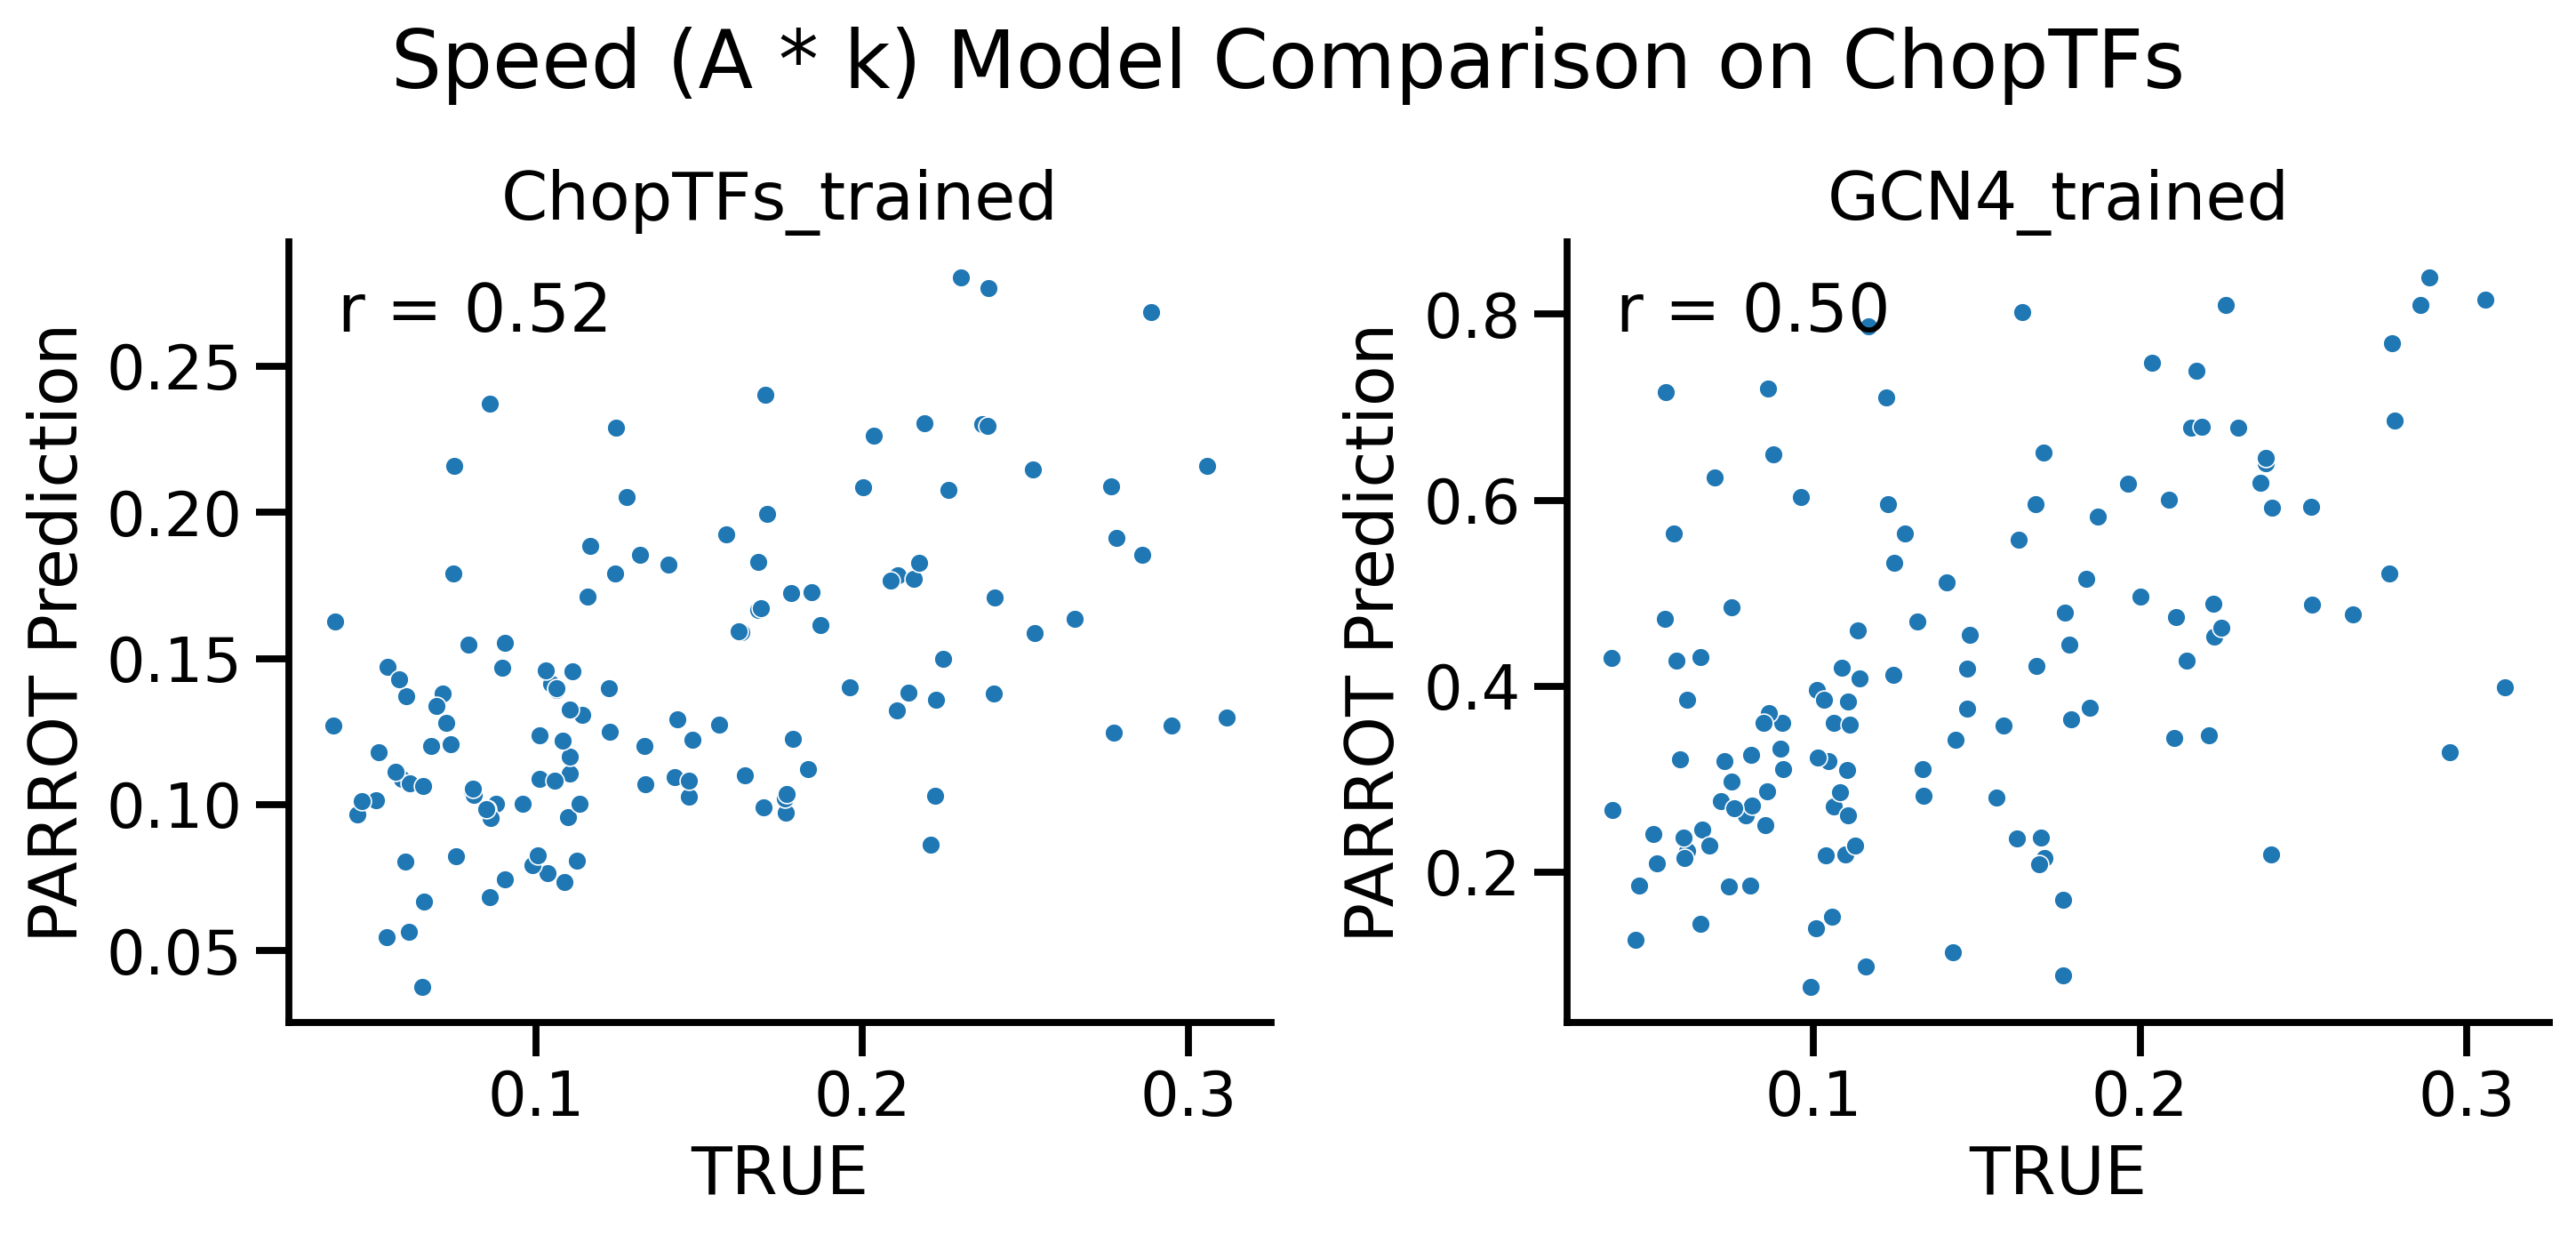

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


sns.set_context("talk")

df = choptf_speed_preds.rename(columns = {"PRED" : "ChopTFs_trained", "GCN4_pred" : "GCN4_trained"})
cols = ["ChopTFs_trained", "GCN4_trained"]
true = df["TRUE"]

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, dpi = 300)

for ax, col in zip(axes, cols):
    x = true
    y = df[col]

    sns.scatterplot(x=x, y=y, ax=ax, s=25, alpha=1)


    # Pearson
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        va="top"
    )

    ax.set_title(f"{col}")
    ax.set_xlabel("TRUE")
    ax.set_ylabel("PARROT Prediction")

fig.suptitle("Speed (A * k) Model Comparison on ChopTFs", y = 0.94)
sns.despine()
plt.tight_layout()
plt.show()

In [22]:
GCN4_train_strength_predictor = py_predictor.Predictor("../../../output/GCN4_pipeline/speed/PARROT/exponential_strength", 
                                                dtype="sequence")
GCN4_train_strength_predictor

In [23]:
choptf_strength_preds["GCN4_pred"] = choptf_strength_preds["seq"].apply(lambda seq: GCN4_train_strength_predictor.predict(seq)[0])
choptf_strength_preds

class,seq,PRED,TRUE,GCN4_pred
0,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.519283,1.972028,4.405672
1,ALPDDLYFTDFVSPFTAAATTSVTTKTVKDTTPATNHMDD,1.143222,1.085339,2.617124
2,ANNDDFDDLLSVASMNSNYLLPVNSHGYKHISNLDELDDL,1.463037,1.452484,3.628022
3,ARDEILPLRLQFNEFIQIMANIDQEGSKQADRMAKYLHIR,0.747855,1.387782,1.869254
4,ASTNTSSALNCQSYTNNQDIMDILFQVTSGSVWDEFFVRS,1.338550,1.852118,3.201563
...,...,...,...,...
122,VSNPGDNPPPADNGEEYLTLNDFNDLNIDWSTTGDNGELD,1.661274,1.754190,4.022415
123,WFWALFLDVSTSYDIGNPPSISDDLLDLSIFTAQNFQSPS,1.446808,1.859544,4.705416
124,WICQMHINQPDYMFSSQLRQDGDIEAQLEAIRYYEDVVVN,1.027500,1.265221,2.644094
125,YEVLCEYLTDFFASDFYDSYQIVHKEKVLRDLQDCFVKGP,1.314954,1.085725,4.079780


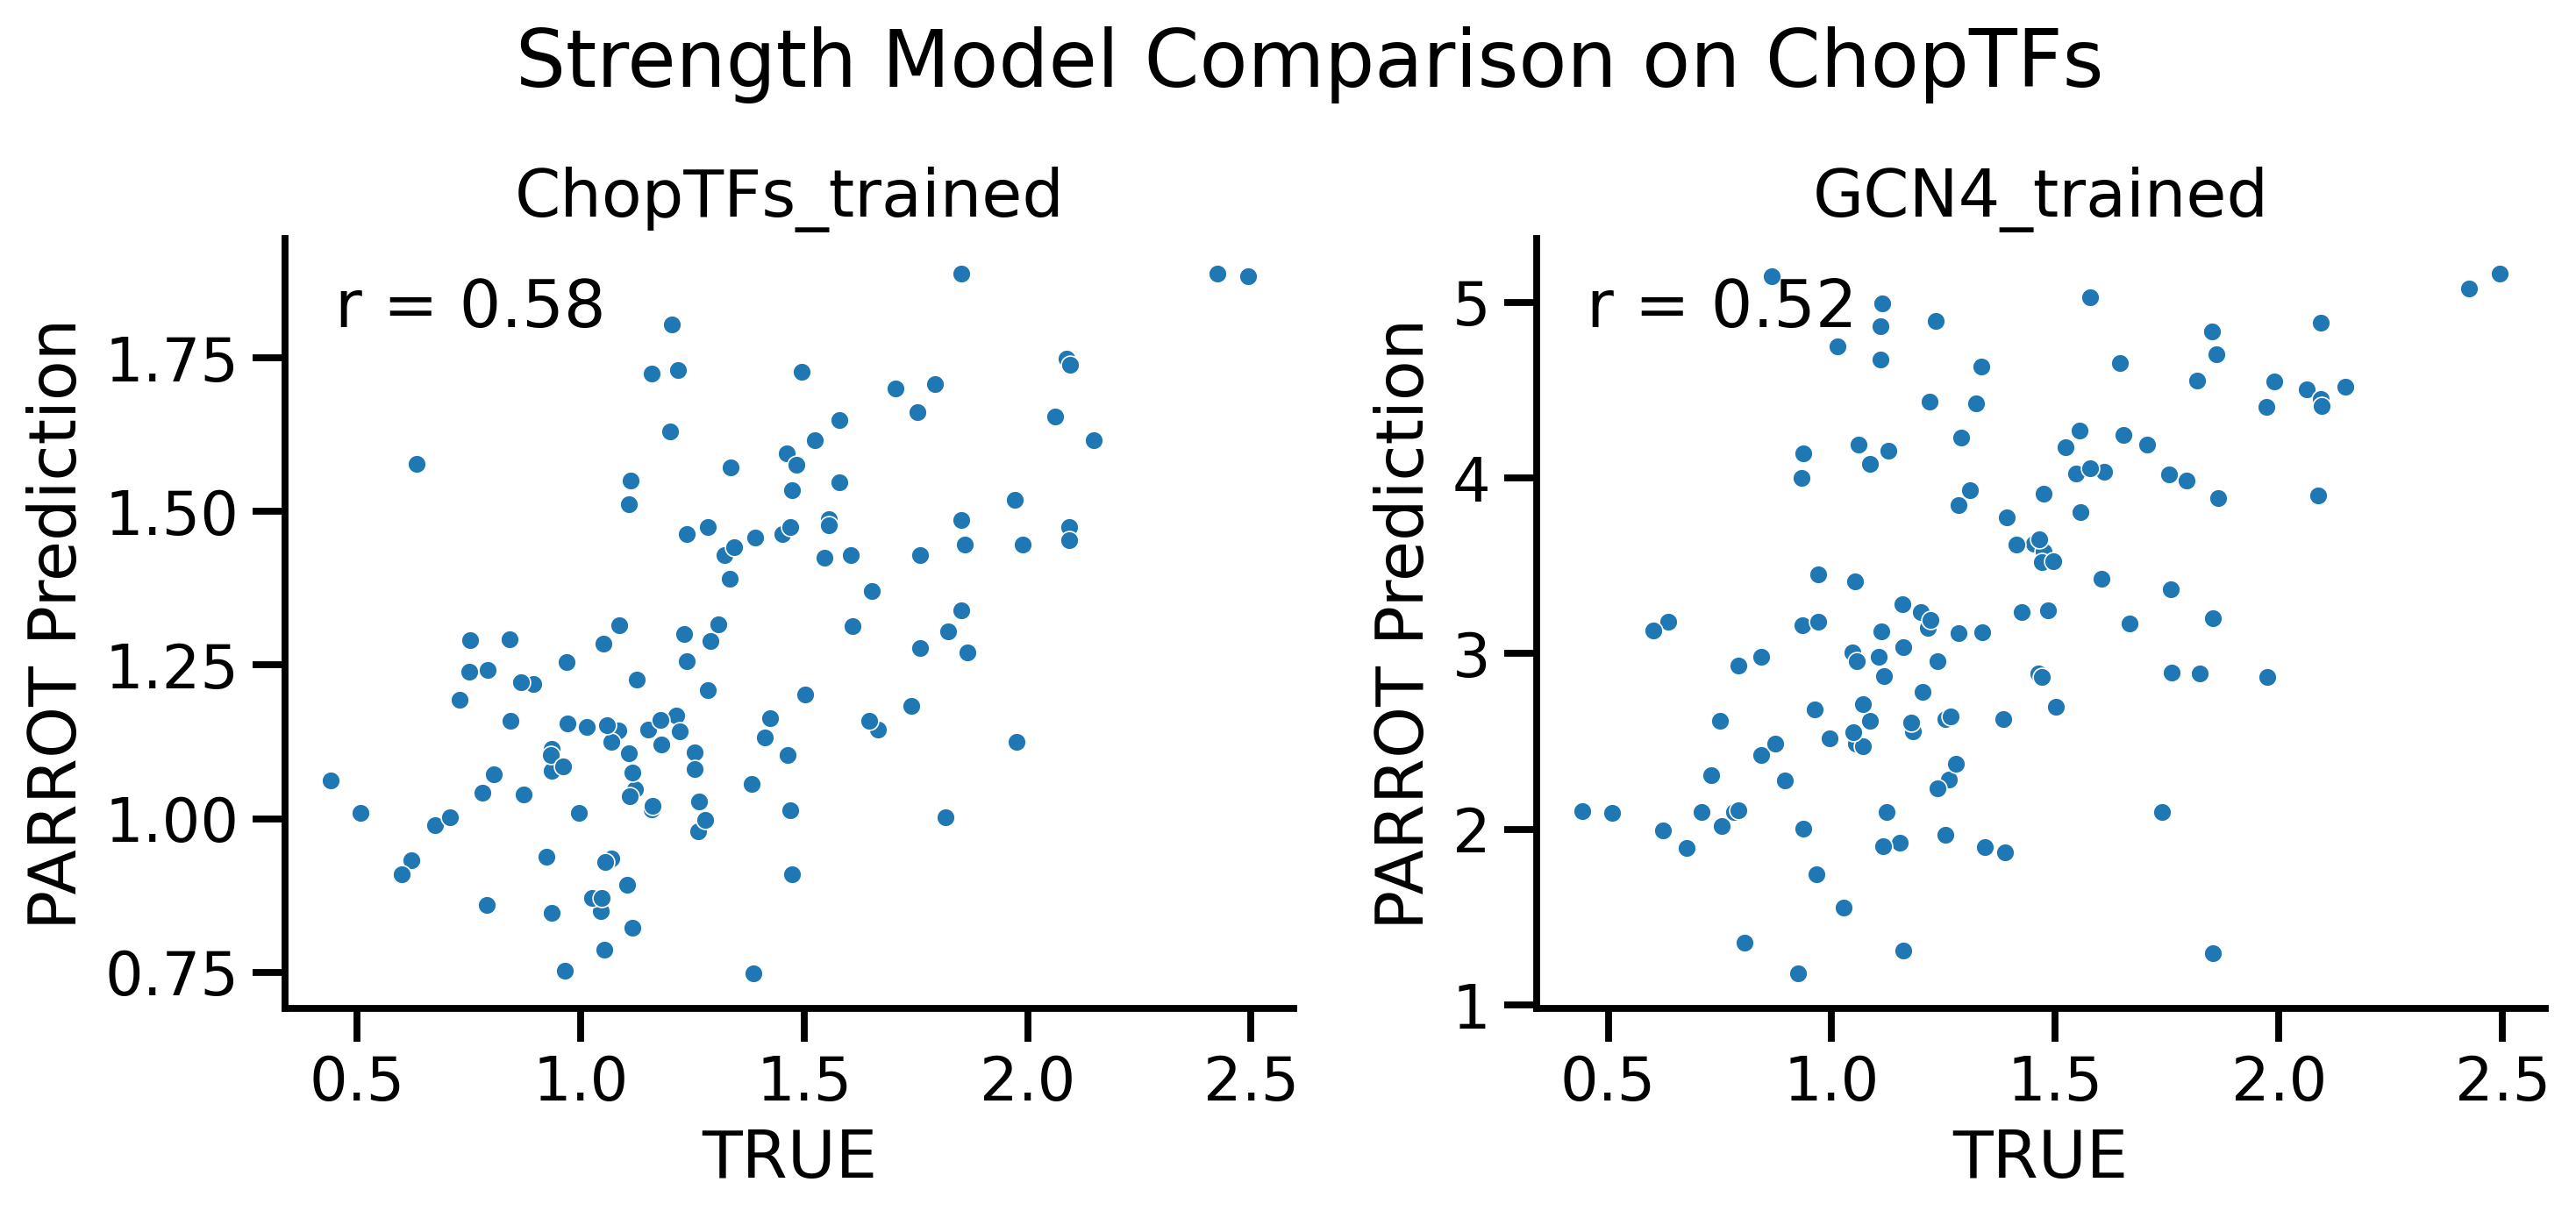

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_context("talk")

df = choptf_strength_preds.rename(columns = {"PRED" : "ChopTFs_trained", "GCN4_pred" : "GCN4_trained"})
cols = ["ChopTFs_trained", "GCN4_trained"]
true = df["TRUE"]

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, dpi = 300)

for ax, col in zip(axes, cols):
    x = true
    y = df[col]

    sns.scatterplot(x=x, y=y, ax=ax, s=25, alpha=1)

    # Pearson
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        va="top"
    )

    ax.set_title(f"{col}")
    ax.set_xlabel("TRUE")
    ax.set_ylabel("PARROT Prediction")

fig.suptitle("Strength Model Comparison on ChopTFs", y = 0.94)
sns.despine()
plt.tight_layout()
plt.show()